# Liquid level control system using Machine Learning
This project is aimed at using the behaviour of a `PID regulator` based control system obtained from `Matlab`
to predict the opening level of the actuating mechanism (i.e. the valve) through various regressors such as `RandomForestRegressor` and `CatBoostRegressor`.
## 1. Problem definition
> How well can a valve's position be predicted using the data obtained from a Matlab simulation of a PID based control system
## 2. Data
> We have data from Matlab-Simulink based models of a PID based liquid level control system at `training_data_from_matlab2.csv`
* The dataset has timestamps in `seconds` format.
* It has the desired input levels of the liquid in meters.
* The output liquid levels in meters as well
* The feedback: The difference the desired output (input) and the actual output.
* Opening levels of the valve in % (0-100)
### 2.1. How to format the data
* We need to check what kind of format, the data under label `Time` are in and then convert them into either datetime.seconds or int64 format (if time data is in string format)
* Convert `string` datatypes to float using `pd.to_numeric(downcast = 'float')`
* Eliminate any missing data by first generating `is_missing` boolean data for each column of the input data
* Then eliminate by checking through `isna().sum()` and `_is_missing.value_counts()` and then eliminating the missing values by replacing them with `medians`
* Eliminate erronious data. I.e. liquid levels above `1.0` in `input` and `liquid_level` columns and valve opening levels above `100` in `valve_positions` by replacing them with medians.
## 3. Modelling
* Use `train_test_split()` from `sklearn` to divide the dataset into training and validation datasets.
* Use `RandomForestRegressor` to train the model using the training dataset.
* Use `CatBoostRegressor` to train the model using the training dataset.
* Use `RandomizedSearchCV` to get the optimize the model using the best hyperparameters `RandomForestRegressor`
* Use `catboostcv` to obtain best hyperparameters for `CatBoostRegressor`
* Evaluate the optimized model on the validation datasets.
* Use test datasets to check the predictions of the model against true labels.
## 4. Saving the model for export and reuse
At this step, we will save the model. 
* Use the `pickle` module to save the models
* Or the `joblib` module to save the models.
  
## 5. Applying the output of the model on the transfer function of the control object
* This purpose can be achieved using the `control` library.
* Use the `control` library to simulate the output liquid level due to the valve opening levels predicted by the models in step 3. 


In [1]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import control as ct
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import pickle
from joblib import load, dump
%matplotlib inline

## 2. Data preparation

We will be using a preprocessing function that takes in data from a provided filepath and then perform all the necessary preprocessing to make sure that the data imported is ready to be used for training. 



In [2]:
def preprocess_data(PROVIDED_FILE_PATH):
    """
    This function is meant to predict the opening level of a valve on the basis of input data, feedback data and timestamps
    The data is to be imported from the datasheets as specified in "FILE_PATH"
    The file will imported to a pandas dataframe
    The time data is to be converted from string to numeric
    A check will be performed to remove string type data, which is to be converted to float type
    Then a check will be performed for any missing data
    Then erroneous data (liquid levels > 1.2 and valve positions > 100) will be replaced with the median values of the respective columns
    The dataframe will be ready for further action!
    """
    # Step-1 read data from the file path
    print("Reading data....")
    df_data = pd.read_csv(PROVIDED_FILE_PATH)
    # Step-2 change the datatype of time column from string to numeric
    # In this case, we need to remove the phrase 'sec' from the column
    #print("Changing the Time data from string to numeric....")
    #df_data["Time"] = df_data["Time"].str.replace(" sec","",regex=True)
    # Then we will have to change the datatype from object to numeric
    #df_data["Time"] = pd.to_numeric(df_data["Time"])
    # Step-3: Check for string type data
    print("Checking for string type data....")
    for label, content in df_data.items():
        if pd.api.types.is_string_dtype(content):
            print("There is string type data in: ",label)
            print("Converting strings to float in: ", label)
            df_data[label] = pd.to_numeric(df_data[label],errors = "coerce")
        else:
            print("There are no strings in: ", label)
    # Step-4: Check for missing data
    print("Checking for missing data....")
    for label, content in df_data.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                print("There are missing values in: ", label)
                df_data[label + "is_missing"] = pd.isnull(content)
                # Now fill the missing data with zeroes
                df_data[label] = content.fillna(0)
            else:
                print("There are no missing values in: ",label)
    # Step-5: Now check for erroneous data
    print("Checking for erroneous data....")
    # In this case first we will be removing any values
    for content in df_data["Liquid_levels"]:
        if (content > 1.5):
            print("Erroneous data found")
            content = df_data["Liquid_levels"].median()
    for content in df_data["Valve_Positions"]:
        if (content > 100.0):
            print("Erroneous data found")
            content = df_data["Valve_Positions"].median()



    print("Preprocessing complete....")
    print(df_data.info())
    return df_data

### 2.1. Preprocess the data

The training data is provided at `training_data_from_matlab24.csv` and the test data is provided at `training_data_from_matlab27.csv`

In [3]:
df_train_data = preprocess_data("training_data_from_matlab24.csv")
df_test_data = preprocess_data("training_data_from_matlab27.csv")

Reading data....
Checking for string type data....
There are no strings in:  Time
There are no strings in:  Input
There are no strings in:  Input_delayed
There are no strings in:  Liquid_levels
There are no strings in:  Error
There are no strings in:  Derivative_error
There are no strings in:  Integral_error
There are no strings in:  Valve_Positions
Checking for missing data....
There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Input_delayed
There are no missing values in:  Liquid_levels
There are no missing values in:  Error
There are no missing values in:  Derivative_error
There are no missing values in:  Integral_error
There are no missing values in:  Valve_Positions
Checking for erroneous data....
Preprocessing complete....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75001 entries, 0 to 75000
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  


## 2.2. Create an overshoot filtering mechanism

In order to make sure that our RandomForestRegressor and CatBoostRegressor models don't learn about overshoot from the training data, an overshoot filtering mechanism needs to be created so as to filter the overshoot/undershoot data from the training data set. 

Two copies of the training data are to be used, one with samples having overshoot, filtered out and the other with the overshoot samples not being removed


In [4]:
class OverShootFilter:
  """
  An overshoot filter class
  args:
      dataframe: Preprocessed dataframe out of data obtained from matlab simulink
      dt: time interval between each sample, default value = 0.1 seconds
      allowable_overshoot: Maximum percentage of overshoot that is to be allowed, default value is 1
      settling_time: Seconds to remove after overshoot peak, default value is set to 250,
      set to lower for more aggressive PID regulator configuration
      and higher for more robust PID regulator configuration
  """
  def __init__(self, dataframe, dt=0.1, allowable_overshoot = 1, settling_time = 250):
    self.dataframe = dataframe.copy()
    self.dt = dt
    self.allowable_overshoot = allowable_overshoot
    self.settling_time = settling_time
    self.settling_samples = int(settling_time/dt) # No. of samples to be removed in case of overshoot filtering
    self.keep_mask = None
    #self.inputs = self.dataframe["Input"].values
    #self.liquid_levels = self.dataframe["Liquid_levels"].values
  def overshoot_detection(self):
    """
    Function to identify overshoot.
    Takes in the setpoint (Input) and the liquid level (Liquid_Levels)
    """
    inputs = self.dataframe["Input"].values
    liquid_levels = self.dataframe["Liquid_levels"].values
    self.keep_mask = np.ones(len(liquid_levels), dtype = bool)
    # Detect all the setpoint changes
    diff_inputs = np.abs(np.diff(inputs))
    input_change_indexes = np.where(diff_inputs > 0.05)[0] + 1

    overregulation_events = [] # An empty list where all the overshoot events are to be recorded

    # Let's detect all the overshoot events now...
    for index in input_change_indexes:
      target = inputs[index]
      if index > 0:
        prev_target = inputs[index-1]
      else:
        prev_target = target
      # Ignore small targets
      if abs(target-prev_target) < 0.1:
        continue
      # Look at the response window
      window_end = min(index + 5000, len(liquid_levels)) # Either the next 5000 samples or the end of the array
      # Look at the reactions
      reaction = liquid_levels[index:window_end]

      if target > prev_target:
         # Rising liquid level and overshoot occurence
         max_liquid_level = np.max(reaction)
         overshoot_amount = abs(max_liquid_level - target)
         allowable = (self.allowable_overshoot / 100) * target

         if (overshoot_amount > allowable):
          # Overshoot amount exceeds allowable limit
          peak_index = index + np.argmax(reaction) # Spotted the index at which the overshoot peak is reached
          start_index = index + np.argmax(reaction > target)
          end_index = min(peak_index + self.settling_samples, (len(liquid_levels))) #Either the no. of settling samples or the end of the array
          self.keep_mask[start_index:end_index] = False
          # Keep a record
          overregulation_events.append({"Time":index * self.dt,
                                        "Overregulation type": "Overshoot",
                                        "Overregulation percentage": (overshoot_amount/target)*100,
                                        "peak_value": max_liquid_level,
                                        "Desired value": target})


      else:
        # Falling liquid level (draining and possible undershoot)
        min_liquid_level = np.min(reaction)
        undershoot_amount = abs(target-min_liquid_level)
        allowable = (self.allowable_overshoot/100)*target

        if(undershoot_amount > allowable):
          # Undershoot exceeds allowable limit
          lowest_index = index + np.argmin(reaction) # Detect the index at which the undershoot is at its lowest
          start_index = index + np.argmax(reaction < target) # Start from the index at which the reaction goes below the target
          end_index = min(lowest_index + self.settling_samples, (len(liquid_levels))) # Either the no. of settling samples or the end of the array
          self.keep_mask[start_index:end_index] = False
          # Keep a record of the undershoots
          overregulation_events.append({"Time": index*self.dt,
                                        "Overregulation type": "Undershoot",
                                        "Overregulation percentage": (undershoot_amount/target)*100,
                                        "Lowest_value": min_liquid_level,
                                        "Desired value": target})



    # Print results
    kept_values = np.sum(self.keep_mask)
    total_samples = len(self.keep_mask)

    print(f"Total overregulation events recorded: {len(overregulation_events)}\n")
    print(f"Kept samples {kept_values} out of {total_samples} \n")
    print(f"Samples to be filtered: {total_samples-kept_values} out of {total_samples} \n")


    # Now for the return
    if overregulation_events:
      print("Overregulation has occured")
      #for event in overregulation_events[:6]:
        # The first six
        #print("Overregulation is occuring")
      return self.keep_mask, overregulation_events
  # A function to create a filtered dataset
  def create_overshoot_filtered_dataset(self, lookback=1500):
    """
    A function to modify the provided dataframe with filtered data...
    This function requires the boolean array keep_mask and also the preprocessed dataframe.
    The boolean array, keep_mask can be obtained using the earlier function "overshoot_detection()"
    which returns the boolean array as well as a dict object containing details about all over-regulation events...
    """
    print(f"No. of( input samples: {self.dataframe.Input.size}")
    keep_mask, overregulation_events = self.overshoot_detection()
    df_keep_mask = pd.DataFrame(keep_mask, columns = ['Mask'])
    #print(f"Keep_mask size: {df_keep_mask.size}")
    #print(f"Mask value counts = {df_keep_mask.value_counts()}")
    modified_dataframe = self.dataframe.copy()
    modified_dataframe["Keep_Mask"] = df_keep_mask.copy()

    print(f"In the modified dataframe we have the masking status: {modified_dataframe['Keep_Mask'].value_counts()}")
    filtered_dataframe = modified_dataframe[modified_dataframe["Keep_Mask"]]
    print(f"Amount of filtered data in the filtered dataframe is: {(modified_dataframe['Liquid_levels'].size-filtered_dataframe['Liquid_levels'].size)/modified_dataframe['Liquid_levels'].size * 100} %")
    plt.figure(figsize = (8,8))
    plt.subplot(2,1,1)
    plt.plot(modified_dataframe["Time"], modified_dataframe["Input"], label = "Unfiltered Inputs")
    plt.plot(modified_dataframe["Time"], modified_dataframe["Liquid_levels"], label = "Unfiltered Outputs")
    plt.legend(loc = "upper right")
    plt.subplot(2,1,2)
    plt.plot(filtered_dataframe["Time"], filtered_dataframe["Input"], label = "Filtered Inputs")
    plt.plot(filtered_dataframe["Time"], filtered_dataframe["Liquid_levels"], label = "Filtered outputs")
    plt.legend(loc = "upper right");
    filtered_dataframe_2 = filtered_dataframe.drop(["Time", "Keep_Mask"], axis = 1)
    return filtered_dataframe_2

In [5]:
train_data_overregulation_filter = OverShootFilter(dataframe = df_train_data)

No. of( input samples: 75001
Total overregulation events recorded: 4

Kept samples 61105 out of 75001 

Samples to be filtered: 13896 out of 75001 

Overregulation has occured
In the modified dataframe we have the masking status: Keep_Mask
True     61105
False    13896
Name: count, dtype: int64
Amount of filtered data in the filtered dataframe is: 18.52775296329382 %


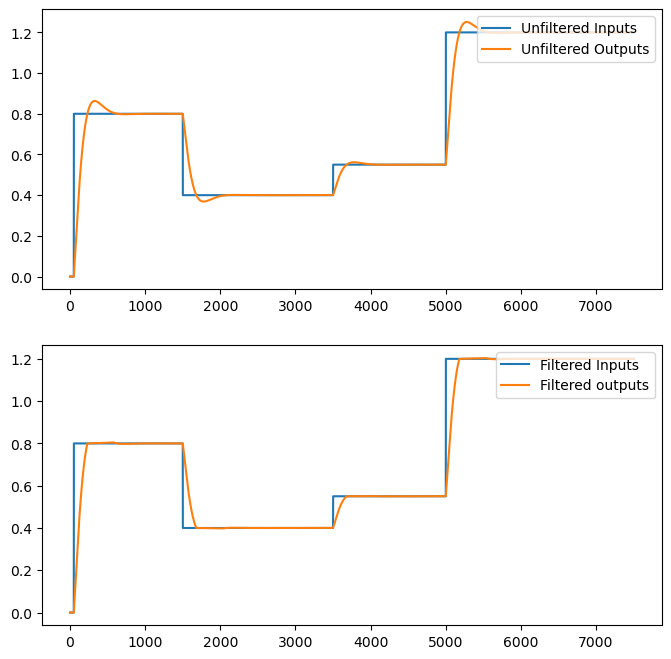

In [6]:
df_train_data_filtered = train_data_overregulation_filter.create_overshoot_filtered_dataset()

Now we have both the filtered and unfiltered data at `df_train_data` and `df_train_data_filtered`. We will be using both of these dataframes to train separate models

In [7]:
# Create a function to separate the features and labels from the dataframe for training and validation/testing
def prepare_for_modelling(DataFrame):
    """
    Function to prepare the data for fitting into the model
    Takes a dataframe as input. Drops the Valve_positions data for X and Valve_positions data is used as y
    X and y are returned
    """
    # If the number of columns in the input DataFrame is 2, i.e. one feature and the label then the feature dataframe has to be modified a bit
    # with pd.DataFrame(DataFrame.drop("Valve_Positions", axis = 1)
          
    if len(DataFrame.columns) >2:
        print("More than one feature")
        
        X = DataFrame.drop("Valve_Positions", axis = 1)
        y = DataFrame["Valve_Positions"]
        return X,y
    elif len(DataFrame.columns) == 2:
        print("One feature and the label")
        X = pd.DataFrame(DataFrame.drop("Valve_Positions", axis = 1))
        y = DataFrame["Valve_Positions"]
        return X,y
    else:
        print("Check the number of columns of the dataframe again")
        print(f"The number of columns: {len(DataFrame.columns)}" )
        return None

In [8]:
# A function to drop Time and Keep_Mask data if they are present (In case they are present)
def drop_time_and_mask(DataFrame):
    """
    Function to drop Time data and Filtering mask (Keep_Mask) data
    if those are present among the columns
    """
    if ("Time" in DataFrame.columns):
        print("Time data provided in the dataframe")
        modified_dataframe = DataFrame.drop("Time", axis = 1)
        if ("Keep_Mask" in modified_dataframe.columns):
            print("Masking data present in dataframe")
            modified_dataframe = modified_dataframe.drop("Keep_Mask", axis = 1)
        print(modified_dataframe.info())
        return modified_dataframe
    else:
        print("Time data not provided in dataframe")
        modified_dataframe = DataFrame.copy()
        if ("Keep_Mask" in DataFrame.columns):
            print("Dropping time data")
            modified_dataframe = modified_dataframe.drop("Keep_Mask", axis = 1)
        print(modified_dataframe.info())
        return modified_dataframe
    

In [9]:
df_train_data_filtered_2 = drop_time_and_mask(df_train_data_filtered)

Time data not provided in dataframe
<class 'pandas.core.frame.DataFrame'>
Index: 61105 entries, 0 to 75000
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             61105 non-null  float64
 1   Input_delayed     61105 non-null  float64
 2   Liquid_levels     61105 non-null  float64
 3   Error             61105 non-null  float64
 4   Derivative_error  61105 non-null  float64
 5   Integral_error    61105 non-null  float64
 6   Valve_Positions   61105 non-null  float64
dtypes: float64(7)
memory usage: 3.7 MB
None


In [10]:
df_test_data_modified = drop_time_and_mask(df_test_data)

Time data provided in the dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40001 entries, 0 to 40000
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             40001 non-null  float64
 1   Input_delayed     40001 non-null  float64
 2   Liquid_levels     40001 non-null  float64
 3   Error             40001 non-null  float64
 4   Derivative_error  40001 non-null  float64
 5   Integral_error    40001 non-null  float64
 6   Valve_Positions   40001 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB
None


In [13]:
df_test_data_modified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40001 entries, 0 to 40000
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             40001 non-null  float64
 1   Input_delayed     40001 non-null  float64
 2   Liquid_levels     40001 non-null  float64
 3   Error             40001 non-null  float64
 4   Derivative_error  40001 non-null  float64
 5   Integral_error    40001 non-null  float64
 6   Valve_Positions   40001 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


In [14]:
df_train_data_unfiltered = drop_time_and_mask(df_train_data)

Time data provided in the dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75001 entries, 0 to 75000
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             75001 non-null  float64
 1   Input_delayed     75001 non-null  float64
 2   Liquid_levels     75001 non-null  float64
 3   Error             75001 non-null  float64
 4   Derivative_error  75001 non-null  float64
 5   Integral_error    75001 non-null  float64
 6   Valve_Positions   75001 non-null  float64
dtypes: float64(7)
memory usage: 4.0 MB
None


### 2.4. Get the features and labels for modelling


In [15]:
# Get the features and labels
X_train_filtered, y_train_filtered = prepare_for_modelling(df_train_data_filtered_2)


More than one feature


In [16]:
X_train_unfiltered, y_train_unfiltered = prepare_for_modelling(df_train_data_unfiltered)

More than one feature


In [17]:
X_test, y_test = prepare_for_modelling(df_test_data_modified)

More than one feature


In [19]:
X_train_filtered.info(), X_train_unfiltered.info(), X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61105 entries, 0 to 75000
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             61105 non-null  float64
 1   Input_delayed     61105 non-null  float64
 2   Liquid_levels     61105 non-null  float64
 3   Error             61105 non-null  float64
 4   Derivative_error  61105 non-null  float64
 5   Integral_error    61105 non-null  float64
dtypes: float64(6)
memory usage: 3.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75001 entries, 0 to 75000
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             75001 non-null  float64
 1   Input_delayed     75001 non-null  float64
 2   Liquid_levels     75001 non-null  float64
 3   Error             75001 non-null  float64
 4   Derivative_error  75001 non-null  float64
 5   Integral_error    75001 non-null  float

(None, None, None)

## 3. Create the ML models for training and testing the data

### 3.1. Create a RandomForestRegressor model

In [20]:
def create_rf_model(metric):
    """
    Creates a RandomForestRegressor model with random_state = 48. 
    The value of metric set by the user will determine that criterion of the RFRegressor.
    The values of metric can be "absolute_error", "squared_error", "friedman_mse", "poisson" 
    If the user passes a value that doesn't belong to the above option, a model will be created with the default criterion i.e. "squared_error"
    """
    print("Creating RandomForestRegressor model")
    match metric:
        case "absolute_error":
            print("The metric is mean absolute error")
            model = RandomForestRegressor(criterion=metric,
                                          n_jobs = -1,
                                          random_state = 48)
            return model
        case "squared_error":
            print("The metric is mean squared error")
            model = RandomForestRegressor(criterion = metric,
                                          n_jobs = -1, 
                                          random_state = 48)
            return model
        case "friedman_mse":
            print("The metric is friedman_mse")
            model = RandomForestRegressor(criterion = metric,
                                          n_jobs = -1,
                                          random_state = 48)
            return model
        case "poisson":
            print("The metric is poisson")
            model = RandomForestRegressor(criterion = metric,
                                          n_jobs = -1,
                                          random_state = 48)
            return model
        case _:
            print("Invalid metric value, creating model with default metric")
            model = RandomForestRegressor(n_jobs = -1,
                                          random_state = 48)
            return model

In [21]:
# One baseline model to train the unfiltered training data
base_rf_model_1 = create_rf_model("absolute_error")

Creating RandomForestRegressor model
The metric is mean absolute error


In [22]:
# One baseline model to train the filtered training data
base_rf_model_2 = create_rf_model("absolute_error")

Creating RandomForestRegressor model
The metric is mean absolute error


### 3.2. Fit the two models with filtered and unfiltered training data

In [23]:
%%time
base_rf_model_1.fit(X_train_unfiltered, y_train_unfiltered)

CPU times: total: 2min 7s
Wall time: 16.7 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [24]:
%%time
base_rf_model_2.fit(X_train_filtered, y_train_filtered)

CPU times: total: 1min 35s
Wall time: 12.6 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

### 3.3. Evaluate the two models


In [25]:
def get_scores(y_true, y_preds):
    """
    Takes the true labels and predicted labels as input. 
    Returns the mae, mse, r2_score, msle and rmsle as output
    """
    print(f"Mean absolute error: {mean_absolute_error(y_true, y_preds)}")
    print(f"Mean squared error: {mean_squared_error(y_true, y_preds)}")
    print(f"Root mean squared error: {root_mean_squared_error(y_true, y_preds)}")
    print(f"R2 score: {r2_score(y_true, y_preds)}")
    print(f"Mean squared log error: {mean_squared_log_error(y_true, y_preds)}")
    print(f"Root mean squared log error: {root_mean_squared_log_error(y_true, y_preds)}")

In [26]:
# Predictions made from model trained on unfiltered data
y_preds_1 = base_rf_model_1.predict(X_test)

In [27]:
# Predictions made from model trained on filtered training data
y_preds_2 = base_rf_model_2.predict(X_test)

Adding a function to make sure that the predictions provide a 0 output every time when the setpoint is 0

In [144]:
def safe_predict(model, X, setpoint_index = 0):
  predictions = model.predict(X)
  setpoint = X.iloc[:,setpoint_index]
  predictions[setpoint<0.01] = 0
  return predictions

In [145]:
y_preds_1_safe = safe_predict(base_rf_model_1, X_test, setpoint_index=0)

In [32]:
y_preds_2_safe = safe_predict(base_rf_model_2, X_test, setpoint_index=0)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_squared_log_error, root_mean_squared_log_error

In [35]:
# Now lets get some scores
get_scores(y_test, y_preds_1_safe)

Mean absolute error: 2.03705331147727
Mean squared error: 5.833870358131646
Root mean squared error: 2.4153406298349815
R2 score: 0.7954976961106595
Mean squared log error: 0.12642542108825866
Root mean squared log error: 0.3555635260938032


In [36]:
get_scores(y_test, y_preds_2_safe)

Mean absolute error: 2.255985140943598
Mean squared error: 7.6235388061870655
Root mean squared error: 2.761075661076144
R2 score: 0.7327621023525208
Mean squared log error: 0.13699130911311377
Root mean squared log error: 0.3701233701255755


#### 3.3.1. Visualize the predicted valve levels

In [148]:
fig_size = (7.5, 6)
def plot_valve_pos(x, y_true, y_preds, fig_size):
    """
    Plots the predicted valve positions as well as the true valve positions against time
    """
    fig, ax = plt.subplots(figsize = fig_size)
    # Plot the true labels 
    ax.plot(x[:15000], y_true[:15000], c = "red", label = "True valve positions")
    # Plot the predicted labels
    ax.plot(x[:15000], y_preds[:15000], c = "blue", label = "Predicted valve positions")
    ax.set(xlabel = "Time (seconds)",
           ylabel = "Valve opening level (%)",
           title = "Valve positions predictions")
    ax.legend();

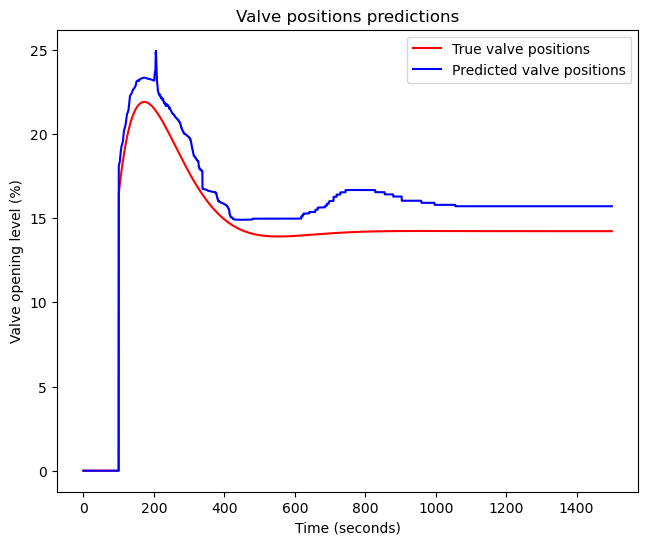

In [149]:
plot_valve_pos(df_test_data.Time, y_test, y_preds_1_safe, fig_size = fig_size)

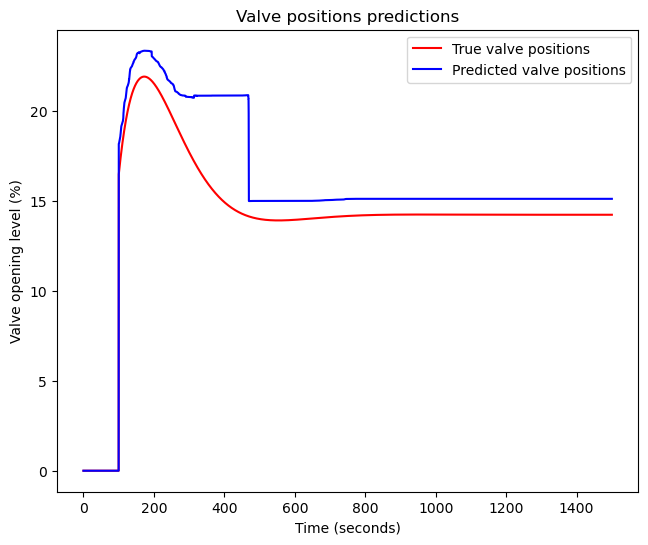

In [150]:
plot_valve_pos(df_test_data.Time, y_test, y_preds_2_safe, fig_size = fig_size)

In [40]:
# Obtain the required transfer function
W_tank = ct.tf([5.2704], [150.58, 1])
W_tank

TransferFunction(array([5.2704]), array([150.58,   1.  ]))

In [151]:
def plot_liquid_levels(W, df, y_true, y_preds,  fig_size):
    """
    A function to plot the predicted liquid level values at the output of the function based on the predicted valve opening levels
    Valve cross-section is required here in order to simulate the regulating valve
    W: Transfer function of the control object
    df: Input dataframe
    """
    # Get a time_vector
    if ("Time" in df.columns):
        time_vector = df.Time
        # Get the forced responses for the true liquid levels 
        time_returned_1, sysout = ct.forced_response(W, time_vector, (y_true/100))
        time_returned_2, sysout2 = ct.forced_response(W, time_vector, (y_preds/100))
        
        # Create the plots
        fig, ax = plt.subplots(figsize = fig_size)
        ax.plot(time_returned_1[:15000], sysout[:15000], c = "red", label = "True liquid levels")
        ax.plot(time_returned_2[:15000], sysout2[:15000], c = "blue", label = "Predicted liquid levels")
        ax.plot(time_returned_2[:15000], df.Input[:15000], c = "green", label = "Setpoint")
        ax.set(xlabel = "Time (seconds",
               ylabel = "Liquid level (m)",
               title = "Liquid level predictions")
        ax.legend();
    else:
        print("Time data unavailable")
    

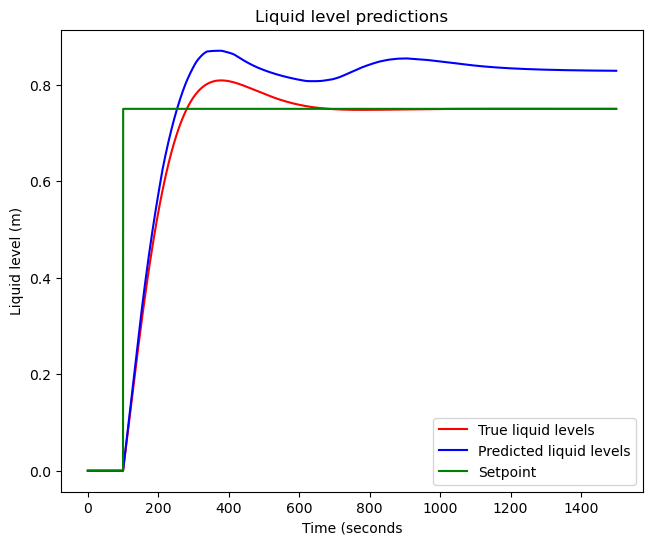

In [152]:
plot_liquid_levels(W = W_tank, df = df_test_data, y_true = y_test, y_preds = y_preds_1_safe, fig_size = (7.5, 6))

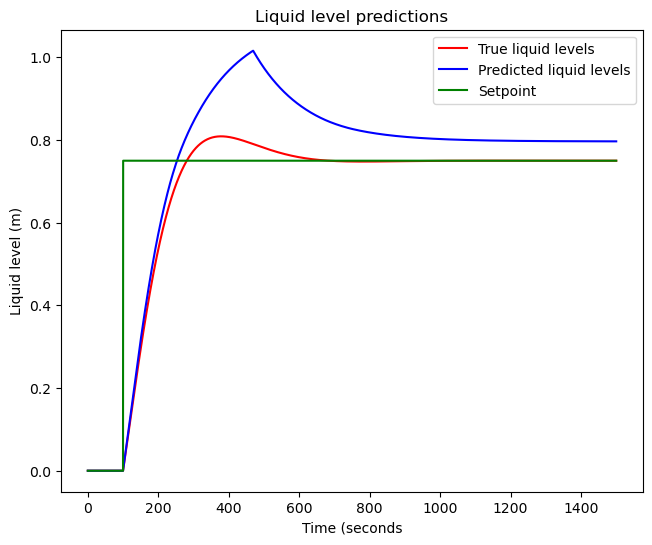

In [153]:
plot_liquid_levels(W = W_tank, df = df_test_data, y_true = y_test, y_preds = y_preds_2_safe, fig_size = (7.5, 6))

### 3.4. Improvization using RF_grid

At this stage, since the baseline models are not exactly giving out great results, we are going to use RF_grid to improvise on the baseline models and try to get better results

In [47]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [50]:
# Prepare the RF_grid
rf_grid = {"n_estimators": np.arange(0, 1500, 10),
           "criterion": ["squared_error", "absolute_error", "poisson", "friedman_mse"],
           "max_depth": [None, 3, 5, 10, 15, 20],
           "min_samples_split": np.arange(2, 60, 2),
           "min_samples_leaf": np.arange(1, 30, 2),
           "max_features": [0.25, 0.5, 1.0, 'sqrt'],
           "max_samples": [None]}

# Prepare the rs_model
rs_model_1 = RandomizedSearchCV(RandomForestRegressor(n_jobs = -1, 
                                                     random_state=45),
                                param_distributions=rf_grid,
                                n_iter=6,
                                cv = 5,
                                verbose = True)
rs_model_2 = RandomizedSearchCV(RandomForestRegressor(n_jobs = -1, 
                                                     random_state=45),
                                param_distributions=rf_grid,
                                n_iter=6,
                                cv = 5,
                                verbose = True)

#### 3.4.1. Fit the RF_grid on the training data, both filtered and unfiltered

In [51]:
rs_model_1.fit(X_train_unfiltered, y_train_unfiltered)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=45)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [None, 3, ...], 'max_features': [0.25, 0.5, ...], 'max_samples': [None], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [53]:
rs_model_2.fit(X_train_filtered, y_train_filtered)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=45)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [None, 3, ...], 'max_features': [0.25, 0.5, ...], 'max_samples': [None], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [55]:
rs_preds_unfiltered = rs_model_1.predict(X_test)

In [56]:
rs_preds_unfiltered_safe = safe_predict(model = rs_model_1, X = X_test, setpoint_index = 0)

In [57]:
rs_preds_filtered = rs_model_2.predict(X_test)

In [58]:
rs_preds_filtered_safe = safe_predict(model = rs_model_2, X = X_test, setpoint_index = 0)

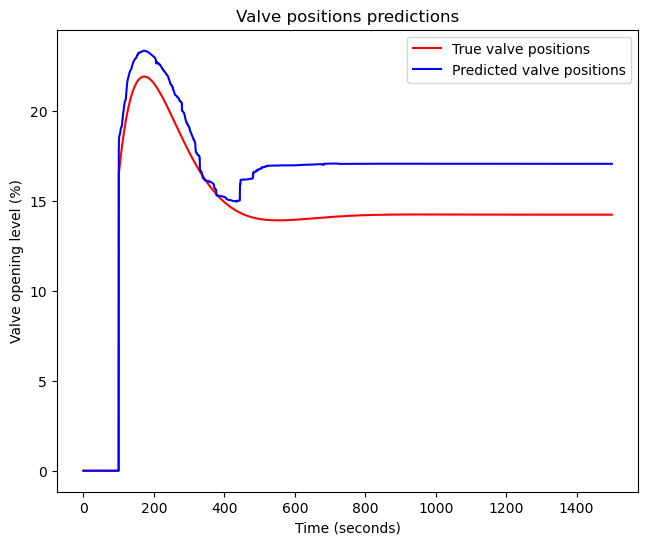

In [154]:
plot_valve_pos(df_test_data.Time, y_test, rs_preds_unfiltered_safe, fig_size = fig_size)

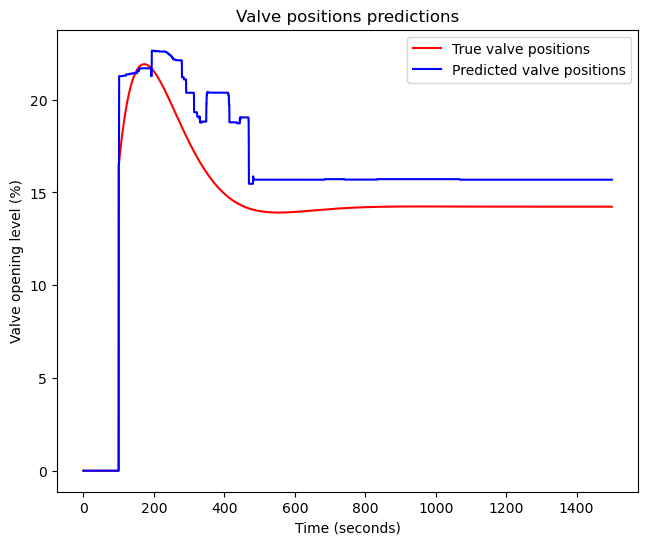

In [155]:
plot_valve_pos(df_test_data.Time, y_test, rs_preds_filtered_safe, fig_size = fig_size)

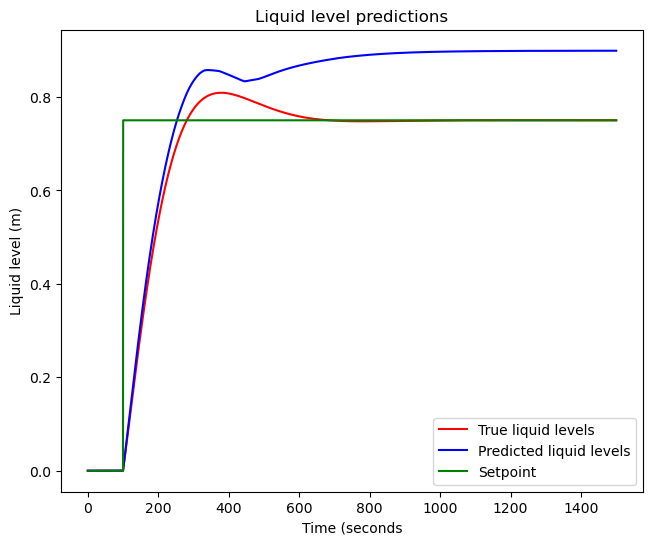

In [156]:
plot_liquid_levels(W = W_tank, df = df_test_data, y_true = y_test, y_preds = rs_preds_unfiltered_safe, fig_size = (7.5, 6))

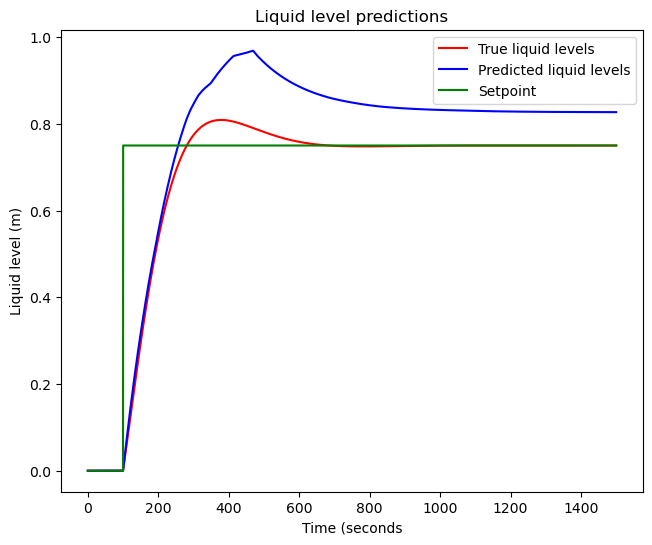

In [157]:
plot_liquid_levels(W = W_tank, df = df_test_data, y_true = y_test, y_preds = rs_preds_filtered_safe, fig_size = (7.5, 6))

### 3.5. Modelling using CatBoostRegressor

`Catboost` is another machine learning library, a bit different from `RandomForestRegressor`, which can also be used to fit and evaluate regression type data that is being used in the concerned control system database

The most important hyperparameters in catboost are:
* iterations
* learning_rate
* depth
* l2_leaf_reg
* model_size_reg
* loss_function
* random_seed
* use_best_model
* cat_features: To specify categorical features, which are absent in case of the databases used for liquid level control system
* feature_weights

#### 3.5.1. Creating a baseling CatBoostRegressor model

In [63]:
catboost_base_model_1 = CatBoostRegressor(iterations = 100,
                                     learning_rate = 0.5,
                                     depth = 8,
                                     loss_function = 'MAE',
                                     random_seed = 48,
                                     use_best_model = None,
                                     verbose = False)
catboost_base_model_2 = CatBoostRegressor(iterations = 100,
                                     learning_rate = 0.5,
                                     depth = 8,
                                     loss_function = 'MAE',
                                     random_seed = 48,
                                     use_best_model = None,
                                     verbose = False)

#### 3.5.2 Fit the baseline models with filtered and unfiltered training data

In [65]:
catboost_base_model_1.fit(X_train_unfiltered, y_train_unfiltered, eval_set = (X_test,  y_test))

In [66]:
catboost_base_model_2.fit(X_train_filtered, y_train_filtered, eval_set = (X_test, y_test))

#### 3.5.3. Visualize the predictions made by the baseline catboost models


In [67]:
catboost_base_preds_unfiltered = catboost_base_model_1.predict(X_test)

In [68]:
catboost_base_preds_filtered = catboost_base_model_2.predict(X_test)

In [71]:
catboost_base_preds_unfiltered_safe = safe_predict(catboost_base_model_1, X_test, setpoint_index = 0)

In [73]:
catboost_base_preds_filtered_safe = safe_predict(catboost_base_model_2, X_test, setpoint_index = 0)

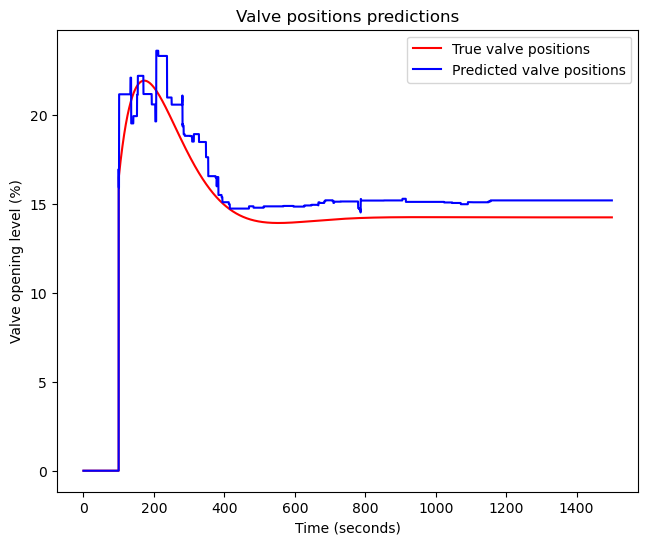

In [158]:
plot_valve_pos(df_test_data.Time, y_test, catboost_base_preds_unfiltered_safe, fig_size = fig_size)

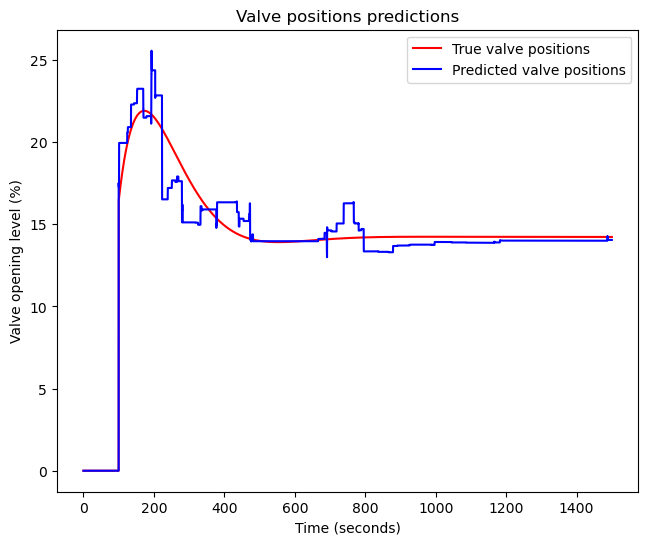

In [159]:
plot_valve_pos(df_test_data.Time, y_test, catboost_base_preds_filtered_safe, fig_size = fig_size)

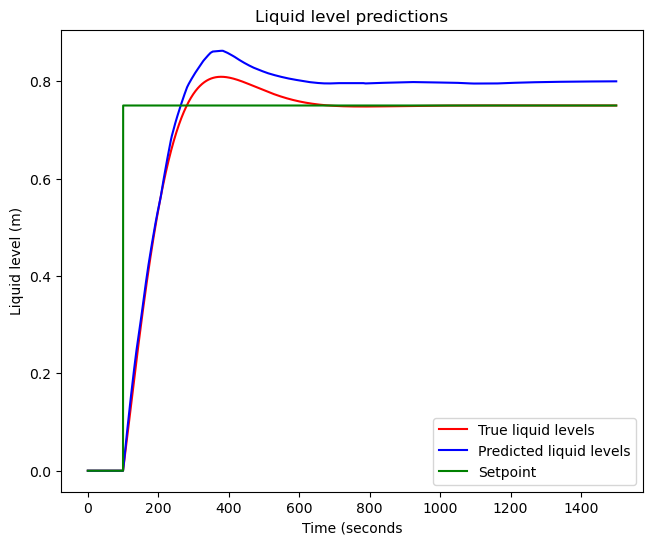

In [160]:
plot_liquid_levels(W = W_tank, df = df_test_data, y_true = y_test, y_preds = catboost_base_preds_unfiltered_safe, fig_size = (7.5, 6))

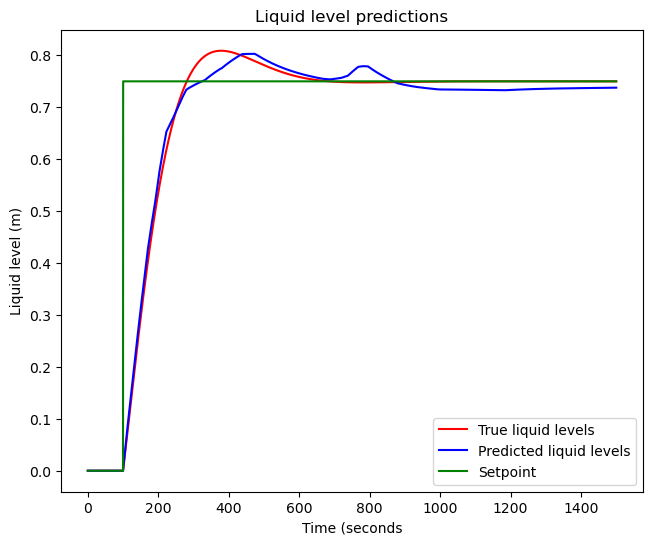

In [161]:
plot_liquid_levels(W = W_tank, df = df_test_data, y_true = y_test, y_preds = catboost_base_preds_filtered_safe, fig_size = (7.5, 6))

In [79]:
X_train_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61105 entries, 0 to 75000
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Input             61105 non-null  float64
 1   Input_delayed     61105 non-null  float64
 2   Liquid_levels     61105 non-null  float64
 3   Error             61105 non-null  float64
 4   Derivative_error  61105 non-null  float64
 5   Integral_error    61105 non-null  float64
dtypes: float64(6)
memory usage: 3.3 MB


In [277]:
catboost_model_2 = CatBoostRegressor(iterations = 250,
                                     learning_rate = 0.45,
                                     depth = 8,
                                     loss_function = 'MultiRMSE',
                                     random_seed = 48,
                                     feature_weights= [0, 0.6, 0.25, 1.5, 0.9, 0.6],
                                     use_best_model = None,
                                     eval_metric= 'MultiRMSE',
                                     verbose = False
                                    )
catboost_model_3 = CatBoostRegressor(iterations = 250,
                                     learning_rate = 0.45,
                                     depth = 8,
                                     loss_function = 'RMSE',
                                     random_seed = 48,
                                     feature_weights= [0, 0.5, 0.42, 1.5, 0.8, 0.6],
                                     use_best_model = None,
                                     eval_metric= 'RMSE',
                                     verbose = False
                                    )

In [278]:
# Fit catboost_model_2 with unfiltered training data
catboost_model_2.fit(X_train_unfiltered, y_train_unfiltered, eval_set = (X_test, y_test))

In [279]:
catboost_model_3.fit(X_train_filtered, y_train_filtered, eval_set = (X_test, y_test))

In [280]:
catboost_preds_2_unfiltered_safe = safe_predict(catboost_model_2, X_test, setpoint_index=0)

In [281]:
catboost_preds_3_filtered_safe = safe_predict(catboost_model_3, X_test, setpoint_index=0)

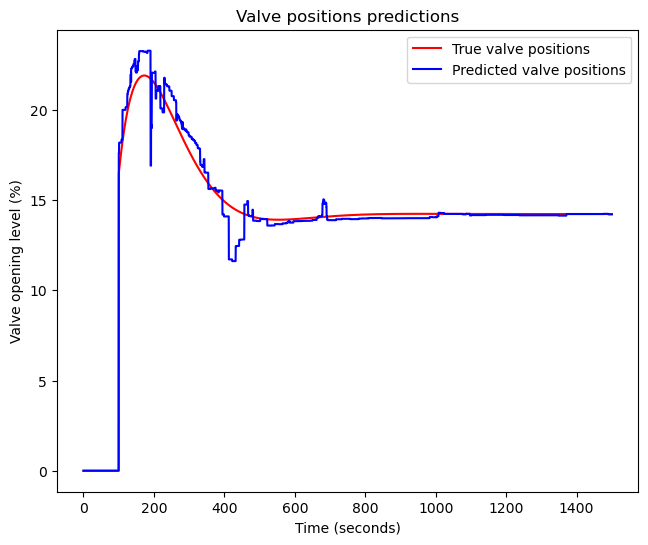

In [282]:
plot_valve_pos(df_test_data.Time, y_test, catboost_preds_2_unfiltered_safe, fig_size = fig_size)

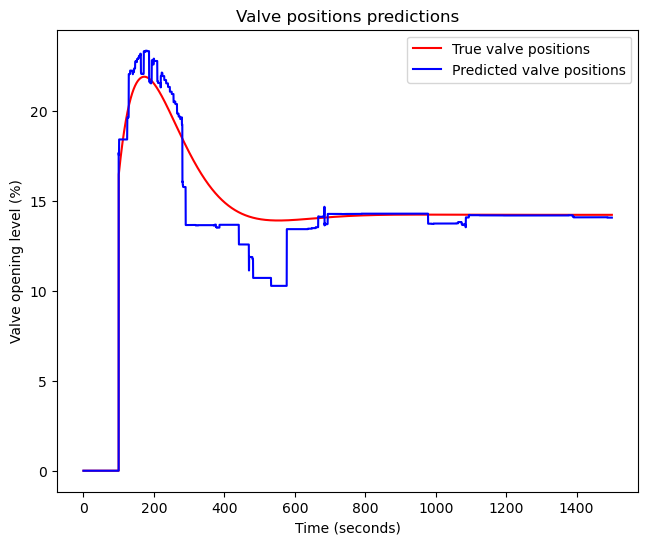

In [283]:
plot_valve_pos(df_test_data.Time, y_test, catboost_preds_3_filtered_safe, fig_size = fig_size)

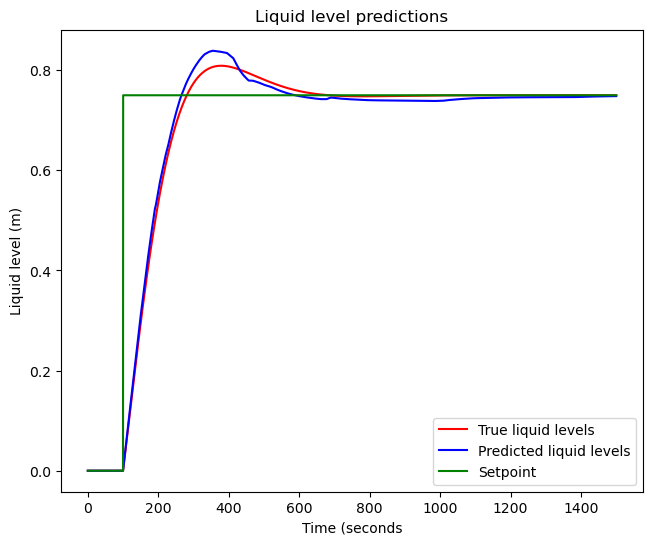

In [284]:
plot_liquid_levels(W_tank, df_test_data, y_test, catboost_preds_2_unfiltered_safe, fig_size)

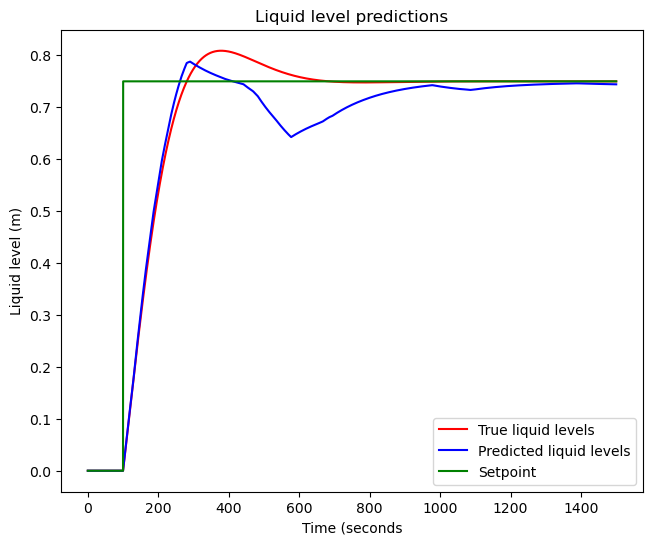

In [285]:
plot_liquid_levels(W_tank, df_test_data, y_test, catboost_preds_3_filtered_safe, fig_size)